# Notebook para preparar los datos y modelación



Este notebook entrena y evalúa los modelos que predicen la salud financiera del año
siguiente a partir de los ratios actuales. Compara una regresión logística con un
random forest, usando una división temporal (entrenar con el pasado y evaluar con el
año más reciente) para una evaluación honesta, y cierra con la interpretación de los
ratios más influyentes y sus implicaciones de gestión.

Entrada: `panel_enriquecido.csv` · Resultado: modelo entrenado en `outputs/`

Se usaran y evaluarán principalmente dos modelos: Regresión logistica y Random Forest

In [1]:
import sys
sys.path.append("..")
import pandas as pd

panel = pd.read_csv("../data/processed/panel_enriquecido.csv")

datos = panel.dropna(subset=["zona_futura"]).copy()
print("Filas modelables:", len(datos))

Filas modelables: 15877


REGRESIÓN LOGISTICA

In [2]:
features = ["razon_corriente", "endeudamiento", "roa", "rotacion_activos"]

X = datos[features]
y = datos["zona_futura"]

Se eligen estas variables por las razones expuestas en 03_eda.
Para entrenamiento y prueba la división se hara temporal y no aleatoria.

Nota: anio=año

In [3]:
# Entrenamiento
train = datos[datos["anio"] <= 2022]
test  = datos[datos["anio"] == 2023]

X_train = train[features]
y_train = train["zona_futura"]
X_test  = test[features]
y_test  = test["zona_futura"]

print("Entrenamiento:", X_train.shape, "| Prueba:", X_test.shape)

Entrenamiento: (12965, 4) | Prueba: (2912, 4)


Se creara un modelo "tonto" como baseline el cual siempre predice la clase mas frecuente para comparar con la regresión logística (modelo real)

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

modelo_log = Pipeline([
    ("imputar", SimpleImputer(strategy="median")),
    ("escalar", RobustScaler()),
    ("clasificador", LogisticRegression(class_weight="balanced", max_iter=1000)),
])

modelo_log.fit(X_train, y_train)

# Linea base
base = DummyClassifier(strategy="most_frequent")
base.fit(X_train, y_train)

print("Exactitud línea base:", round(base.score(X_test, y_test), 3))
print("Exactitud regresión logística:", round(modelo_log.score(X_test, y_test), 3))

Exactitud línea base: 0.602
Exactitud regresión logística: 0.669


La línea base saca 60% prediciendo siempre "segura", pero es inútil: nunca detecta una empresa en riesgo. La regresión logística balanceada revelo solo un poco más de exactitud 0.669. Este modelo sacrifica algo de exactitud global a cambio de sí identificar a las empresas en peligro. Por eso la exactitud es una métrica engañosa aquí, y no es como se debería juzgar el modelo. La evaluación de verdad se hara mediante matriz de confusión y el recall por clase.

              precision    recall  f1-score   support

        gris       0.29      0.50      0.37       452
      riesgo       0.67      0.58      0.62       707
      segura       0.87      0.75      0.80      1753

    accuracy                           0.67      2912
   macro avg       0.61      0.61      0.60      2912
weighted avg       0.73      0.67      0.69      2912



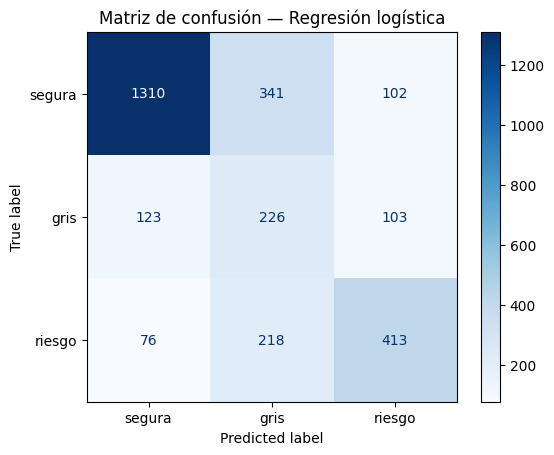

In [5]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predicciones sobre el conjunto de prueba
y_pred = modelo_log.predict(X_test)

# Métricas por clase
print(classification_report(y_test, y_pred))

# Matriz de confusión
ConfusionMatrixDisplay.from_estimator(
    modelo_log, X_test, y_test,
    labels=["segura", "gris", "riesgo"], cmap="Blues"
)
plt.title("Matriz de confusión — Regresión logística")
plt.savefig("../outputs/matriz_confusion_logistica.png", dpi=150, bbox_inches="tight")
plt.show()

RANDOM FOREST

              precision    recall  f1-score   support

        gris       0.37      0.42      0.40       452
      riesgo       0.69      0.71      0.70       707
      segura       0.88      0.83      0.85      1753

    accuracy                           0.74      2912
   macro avg       0.65      0.66      0.65      2912
weighted avg       0.75      0.74      0.75      2912



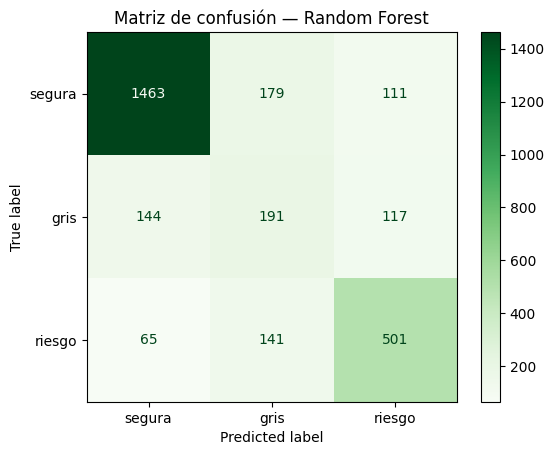

In [7]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = Pipeline([
    ("imputar", SimpleImputer(strategy="median")),
    ("clasificador", RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=115)),
])

modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

ConfusionMatrixDisplay.from_estimator(
    modelo_rf, X_test, y_test,
    labels=["segura", "gris", "riesgo"], cmap="Greens"
)
plt.title("Matriz de confusión — Random Forest")
plt.savefig("../outputs/matriz_confusion_rf.png", dpi=150, bbox_inches="tight")
plt.show()

## Comparación de modelos: regresión logística vs. random forest

### Cómo se evaluo

Como el problema está desbalanceado (aprox 60% de las empresas se mantienen "seguras"), la **exactitud global no basta**: un modelo que predijera siempre "segura" alcanzaría 60% sin detectar ninguna empresa en peligro. Por eso, en un sistema de alerta temprana, la métrica prioritaria es el **recall de la clase "riesgo"** (qué fracción de las empresas que realmente se deterioran logramos detectar) y, sobre todo, minimizar los **errores peligrosos**: clasificar como "segura" a una empresa que terminará en riesgo. Como referencia, una línea base que siempre predice la clase mayoritaria obtiene una exactitud de 0.60.

### Regresión logística (modelo de referencia interpretable)

Exactitud global: **0.67** (supera la línea base de 0.60).

Detecta el 58% de las empresas que caen en riesgo. De las 707 empresas en riesgo real del conjunto de prueba, clasifica 413 como "riesgo", 218 como "gris" y solo 76 como "segura": el 89% de las empresas en peligro quedan marcadas al menos en zona de vigilancia, y los errores peligrosos (riesgo confundido con segura) son apenas el 11%. La clase "gris" es la más difícil (precisión 0.29), algo esperable por ser la zona de transición ambigua entre salud y deterioro.

### Random Forest

Exactitud global: **0.74**.

Mejora en todas las métricas relevantes. Detecta el 71% de las empresas en riesgo (501 de 707), reduce los errores peligrosos a 65 casos (9%) y eleva el F1 de "riesgo" de 0.62 a 0.70. También identifica mejor a las empresas "seguras" (recall 0.83). La clase "gris" sigue siendo la más difícil en ambos modelos, lo que confirma que la dificultad es inherente a la zona intermedia y no a un modelo en particular.

### Conclusión: por qué el Random Forest

Se elige el random forest como modelo final por tres razones:

1. **Mejor desempeño en la métrica que importa.** Eleva el recall de "riesgo" del 58% al 71%, detectando más empresas en peligro, el objetivo central de un sistema de alerta temprana.
2. **Menos errores costosos.** Reduce los casos en que una empresa en riesgo se clasifica como "segura", el error de mayor consecuencia para la gestión.
3. **Captura relaciones no lineales.** A diferencia de la regresión logística, que asume una relación lineal entre los ratios y la salud, el random forest modela umbrales e interacciones (por ejemplo, que el endeudamiento pese solo por encima de cierto nivel), lo que se ajusta mejor a la naturaleza de los ratios financieros.

La regresión logística se conserva como modelo de referencia interpretable, útil para entender la dirección de cada efecto, y el random forest se usa como predictor final por su mayor capacidad de detección.

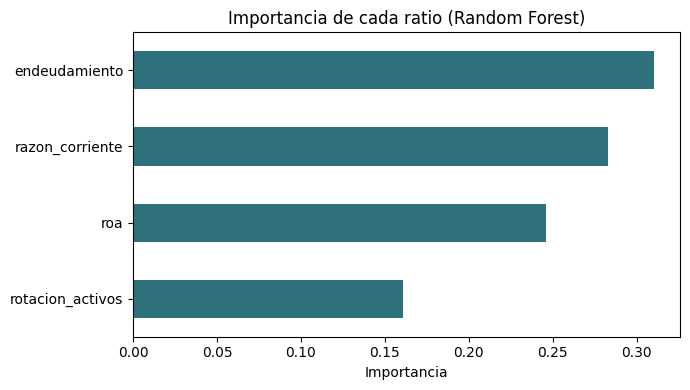

endeudamiento       0.310236
razon_corriente     0.282785
roa                 0.246021
rotacion_activos    0.160959
dtype: float64


In [8]:
# Importancia de las variables, qué ratios pesarn más en las predicciones del modelo
import pandas as pd

importancias = pd.Series(
    modelo_rf.named_steps["clasificador"].feature_importances_,
    index=features
).sort_values(ascending=True)

plt.figure(figsize=(7, 4))
importancias.plot(kind="barh", color="#2e717d")
plt.title("Importancia de cada ratio (Random Forest)")
plt.xlabel("Importancia")
plt.tight_layout()
plt.savefig("../outputs/importancia_ratios.png", dpi=150, bbox_inches="tight")
plt.show()

print(importancias.sort_values(ascending=False))

## Interpretación: ratios clave y palancas de gestión

### Qué ratios pesan más (Random Forest)

El modelo confirma lo observado en el análisis exploratorio (03_eda): las tres dimensiones que más anticipan el deterioro son el **apalancamiento, la liquidez y la rentabilidad**, con pesos similares, mientras que la **eficiencia** queda claramente rezagada. La importancia indica cuáles ratios mandan; la dirección de cada efecto se conoce por los diagramas de caja elaborados en el EDA.

### De los ratios a las decisiones de gestión

Combinando la importancia (qué pesa) con la dirección (cómo pesa), las palancas que más influyen en la salud financiera futura de una empresa son, en orden:

1. **Endeudamiento.** Un apalancamiento alto hoy precede al deterioro. Una empresa con este perfil debería priorizar la reducción y reestructuración de su deuda.
2. **Liquidez.** Una razón corriente baja anticipa problemas. La gestión del capital de trabajo como acelerar la cobranza, controlar inventarios y escalonar pagos, es una palanca relevante de segundo orden.
3. **Rentabilidad.** Un ROA bajo o negativo precede al riesgo. Proteger la rentabilidad operativa (márgenes, control de costos) es la tercera prioridad.
4. **Eficiencia** La rotación de activos casi no anticipa el deterioro: mejorar la productividad de los activos, por sí sola, no previene los problemas financieros.

### Cierre: coherencia entre datos, modelo y teoría

Tres piezas independientes apuntan a lo mismo. El **análisis exploratorio** mostró que el apalancamiento, la liquidez y la rentabilidad separan a las empresas que se deterioran de las que no, y que la eficiencia no. El **random forest** confirma ese mismo orden de importancia sin que se le indicara. Y la eficiencia (la rotación de activos, equivalente al término ventas/activos) resulta ser justo el ratio que el Z''-Score para mercados emergentes descarta de su fórmula: los datos colombianos usados en el presente validan empíricamente la elección metodológica de Altman.

En conjunto, el proyecto entrega a la gestión interna una herramienta de alerta temprana y un mensaje claro a las empresas colombianas: la salud financiera futura se juega, ante todo, en el manejo de la deuda, la liquidez y la rentabilidad.

In [9]:
import joblib

# (imputador + random forest)
joblib.dump(modelo_rf, "../outputs/modelo_random_forest.joblib")
print("Modelo guardado en outputs/")

# Comprobación
modelo_cargado = joblib.load("../outputs/modelo_random_forest.joblib")
print("Prueba de carga:", modelo_cargado.predict(X_test[:5]))

Modelo guardado en outputs/
Prueba de carga: ['gris' 'segura' 'gris' 'riesgo' 'segura']
